In [ ]:
import ast
import pandas as pd
import numpy as np
import ipynbname
from Testing.DRTLO_GD_R2 import *
from Functions.AutoCloud import *
from Functions.Utils import *
from Functions.Graphs import *
from Functions.TedaGraphs import *
import optuna
from optuna.samplers import RandomSampler
from optuna.exceptions import TrialPruned

FileName = ipynbname.name()
study_dir = f'Optimization/{FileName}/'
out_path = f'Optimization/{FileName}/Optimization.csv'
study_dir = os.path.normpath(study_dir)
out_path = os.path.normpath(out_path)

os.makedirs(study_dir, exist_ok=True)

RS = pd.read_excel(r'Dataset\RS.xlsx')
HI = pd.read_csv(r'Dataset\Bearing1_1.csv')
sig = HI['PC1'].values

def to_nearest_pow10(val):
    return 10 ** np.round(np.log10(val))

def SelSampler(mode='auto'):
    '''mode: auto, random,  tpe'''
    if mode == 'auto':
        sampler = None
    elif mode == 'tpe':
        sampler = optuna.samplers.TPESampler(multivariate=True,group=True,n_startup_trials=1000)
    elif mode == 'random':
        sampler=RandomSampler()
    return sampler


In [ ]:
params =  [2.0, 5, '[58, 11, 64, 31, 32]', 15, 5, 0.0754386941522406,6.688979613494848e-06, 0.0029919547064531, 10.168345750070529,'ahead', 'tanh']

m,nI,nR,nO,mO,N1,N2,N3,τ,mode,act = params
X, Y, Z = PrepareData(RS, HI, nI, nO, mO, 1, mode)
nI = len(Y[0])
if isinstance(nR, str): nR = ast.literal_eval(nR)

teda=AutoCloud(m=m,nI=nI,nR=nR,nO=nO+mO,ηS=[N1,N2,N3],mode=mode,act=act,
               tau=τ,rho=0.001,eol=0.3,ref=len(sig)-nI+1,wtaG=True,wtaP=True) 
for j,_ in enumerate(X[:]):
    teda.run(X[j])
    teda.RUL_Prediction(Y[j],mode='interval',lim=len(sig)-nI+1,show=False)
    teda.Adapt(Y[j],Z[j])

teda.c = np.append(teda.c,teda.gm)  
PlotDSI_3D_PLT(teda)


In [ ]:
print(xxx)

In [ ]:
df2 = []
nMax = 20
names = ['MAPE_RUL', 'MAPE_HI', 'm', 'nI', 'nR', 'nO', 'mO', 'N1', 'N2', 'N3','TAU','past/ahead','activation']
for i in range(1):
    print('iteration:',i+1)
    def objective(trial):
        m = trial.suggest_float('m', 1.75, 4.25,step=0.25)
        nI = trial.suggest_int('nI', 2, nMax) 
        n_layers = trial.suggest_int('n_layers', 1, 4)
        nR = [trial.suggest_int(f'nR_layer_{l}', 1, 60) for l in range(n_layers)]
        nO = trial.suggest_int('nO', 8, nMax) 
        mO = trial.suggest_int('mO', 0, nMax) 
        N1 = trial.suggest_int('N1', 1, 9)
        N2 = trial.suggest_int('N2', 1, 9)
        N3 = trial.suggest_int('N3', 1, 9)
        τ = trial.suggest_float('τ', 1, 25,log=True)
        mode = trial.suggest_int('mode', 1,1)  
        act = trial.suggest_int('act', 0,1)  
        n1,n2,n3 = (1/(10**N1)),(1/(10**N2)),(1/(10**N3))
        if mode == 'past':
            if nO > nI: raise TrialPruned()
        elif mode == 'ahead':
            if nI> nMax or nO> nMax: raise TrialPruned()
            elif mO > nI: raise TrialPruned()
            
        X, Y, Z = PrepareData(RS, HI, nI, nO, mO, 1, mode)
        nI = len(Y[0])

        
        teda=AutoCloud(m=m,nI=nI,nR=nR,nO=nO+mO,ηS=[n1,n2,n3],mode=mode,act=act,
                    tau=τ,rho=0.0,eol=0.3,ref=len(sig)-nI+1,wtaG=True,wtaP=True) 
        for j,_ in enumerate(X[:]):
            teda.run(X[j])
            teda.RUL_Prediction(Y[j],mode='single',lim=len(sig)-nI+1)
            teda.Adapt(Y[j],Z[j])

            trial.report(teda.wape_RUL, j)

            if trial.should_prune():
                raise optuna.TrialPruned()

            '''if j == 25:
                if teda.wape_RUL > 0.5: raise TrialPruned()
                if teda.wape_HI  > 0.5: raise TrialPruned()

            if j > 70 or j%25==0:
                if teda.wape_RUL > 0.5: raise TrialPruned()
                if teda.wape_HI  > 0.5: raise TrialPruned()'''

        return teda.wape_RUL, teda.wape_HI

    pruner=optuna.pruners.HyperbandPruner()
    study = optuna.create_study(
        directions=['minimize','minimize'],pruner=pruner,
        sampler=SelSampler(mode='tpe'))

    study.optimize(objective, n_trials=50, timeout=900)
    trials = study.best_trials
    trials_errors = [list(trial.values) for trial in trials]
    trials_params = [list(trial.params.values()) for trial in trials]

    for trial in study.best_trials:
        p = trial.params
        nR_list = [p[f'nR_layer_{l}'] for l in range(p['n_layers'])]
        row = [trial.values[0],trial.values[1],p['m'],p['nI'],str(nR_list),p['nO'],p['mO'],p['N1'],p['N2'],p['N3'],p['τ'],p['mode'],p['act']]
        df2.append(row)

df2 = pd.DataFrame(df2, columns=names)

if os.path.isfile(out_path) and out_path.startswith(study_dir):
    df1 = pd.read_csv(out_path)
    df_stdy = pd.concat([df1, df2], ignore_index=True)

else: df_stdy = df2

df_stdy.to_csv(out_path, index=False)
opt_path = os.path.join(study_dir,f'opt_{len(os.listdir(study_dir))-1}.csv')
df2.to_csv(opt_path, index=False)


In [54]:
df2 = []
nMax = 20
names = ['MAPE_RUL*MAPE_HI', 'm', 'nI', 'nR', 'nO', 'mO', 'N1', 'N2', 'N3','TAU','past/ahead','activation']
for i in range(1):
    print('iteration:',i+1)
    def objective(trial):
        m = trial.suggest_float('m', 1.75, 4.25,step=0.25)
        nI = trial.suggest_int('nI', 2, nMax) 
        n_layers = trial.suggest_int('n_layers', 2, 2)
        nR = [trial.suggest_int(f'nR_layer_{l}', 1, 60) for l in range(n_layers)]
        nO = trial.suggest_int('nO', 8, nMax) 
        mO = trial.suggest_int('mO', 0, nMax) 
        N1 = trial.suggest_int('N1', 1, 9)
        N2 = trial.suggest_int('N2', 1, 9)
        N3 = trial.suggest_int('N3', 1, 9)
        τ = trial.suggest_float('τ', 1, 25,log=True)
        mode = trial.suggest_int('mode', 1,1)  
        act = trial.suggest_int('act', 0,1)  
        n1,n2,n3 = (1/(10**N1)),(1/(10**N2)),(1/(10**N3))
        if mode == 'past':
            if nO > nI: raise TrialPruned()
        elif mode == 'ahead':
            if nI> nMax or nO> nMax: raise TrialPruned()
            elif mO > nI: raise TrialPruned()
            
        X, Y, Z = PrepareData(RS, HI, nI, nO, mO, 1, mode)
        nI = len(Y[0])

        
        teda=AutoCloud(m=m,nI=nI,nR=nR,nO=nO+mO,ηS=[n1,n2,n3],mode=mode,act=act,
                    tau=τ,rho=0.0,eol=0.3,ref=len(sig)-nI+1,wtaG=True,wtaP=True) 
        for j,_ in enumerate(X[:]):
            teda.run(X[j])
            teda.RUL_Prediction(Y[j],mode='single',lim=len(sig)-nI+1)
            teda.Adapt(Y[j],Z[j])

            if j%25 == 0:
                trial.report(teda.wape_RUL+teda.wape_HI, j)
            if trial.should_prune():
                raise optuna.TrialPruned()
            '''if j == 50:
                if teda.wape_RUL > 0.25: raise TrialPruned()
                if teda.wape_HI  > 0.25: raise TrialPruned()

            if len(teda.wape_HI_hist==50):
                if np.sum(teda.wape_HI_hist[:50])/50 > 0.35: raise TrialPruned()
            if len(teda.wape_RUL_hist==50):
                if np.sum(teda.wape_RUL_hist[:50])/50 > 0.35: raise TrialPruned()
            if trial.should_prune():
                raise optuna.TrialPruned()'''

        return teda.wape_RUL+teda.wape_HI

    pruner=optuna.pruners.HyperbandPruner()
    study = optuna.create_study(
        direction='minimize',pruner=pruner,
        sampler=SelSampler(mode='tpe'))

    study.optimize(objective, n_trials=5000, timeout=900)
    trials = study.best_trials
    trials_errors = [list(trial.values) for trial in trials]
    trials_params = [list(trial.params.values()) for trial in trials]

    for trial in study.best_trials:
        p = trial.params
        nR_list = [p[f'nR_layer_{l}'] for l in range(p['n_layers'])]
        row = [trial.values[0],p['m'],p['nI'],str(nR_list),p['nO'],p['mO'],p['N1'],p['N2'],p['N3'],p['τ'],p['mode'],p['act']]
        df2.append(row)

df2 = pd.DataFrame(df2, columns=names)

if os.path.isfile(out_path) and out_path.startswith(study_dir):
    df1 = pd.read_csv(out_path)
    df_stdy = pd.concat([df1, df2], ignore_index=True)

else: df_stdy = df2

df_stdy.to_csv(out_path, index=False)
opt_path = os.path.join(study_dir,f'opt_{len(os.listdir(study_dir))-1}.csv')
df2.to_csv(opt_path, index=False)


[I 2026-08-07 16:13:07,717] Trial 4773 finished with value: 1.9519462522157236 and parameters: {'m': 2.75, 'nI': 7, 'n_layers': 2, 'nR_layer_0': 48, 'nR_layer_1': 60, 'nO': 16, 'mO': 2, 'N1': 2, 'N2': 8, 'N3': 9, 'τ': 2.3021732355096485, 'mode': 1, 'act': 1}. Best is trial 2211 with value: 0.09785979994209804.
[I 2026-08-07 16:13:07,795] Trial 4774 pruned. 
[I 2026-08-07 16:13:07,898] Trial 4775 pruned. 
[I 2026-08-07 16:13:08,164] Trial 4776 pruned. 
[I 2026-08-07 16:13:08,308] Trial 4777 pruned. 
[I 2026-08-07 16:13:08,456] Trial 4778 pruned. 
[I 2026-08-07 16:13:08,530] Trial 4779 pruned. 
[I 2026-08-07 16:13:08,674] Trial 4780 pruned. 
[I 2026-08-07 16:13:08,789] Trial 4781 pruned. 
[I 2026-08-07 16:13:09,229] Trial 4782 pruned. 
[I 2026-08-07 16:13:09,308] Trial 4783 pruned. 
[I 2026-08-07 16:13:09,386] Trial 4784 pruned. 
[I 2026-08-07 16:13:09,495] Trial 4785 pruned. 
[I 2026-08-07 16:13:09,576] Trial 4786 pruned. 
[I 2026-08-07 16:13:09,703] Trial 4787 pruned. 
[I 2026-08-07 16

In [55]:
optuna.visualization.plot_parallel_coordinate(study)

In [59]:
df_params = pd.read_csv(out_path)
#df_params = pd.read_csv(opt_path)
df_params = df_params[(df_params['MAPE_RUL*MAPE_HI'] <= 0.15)]
params_list = df_params.values[:,1:]
df_params

,MAPE_RUL*MAPE_HI,m,nI,nR,nO,mO,N1,N2,N3,TAU,past/ahead,activation
14,0.134511,3.75,11,[21],14,7,1,5,7,12.471656,1,0
16,0.113601,3.75,4,"[12, 39, 60]",18,17,1,8,5,1.005530,1,0
21,0.114847,3.00,19,"[53, 20, 30]",11,5,1,9,9,1.630404,1,1
28,0.119588,3.00,12,"[10, 36]",12,6,1,1,4,1.129253,1,0
46,0.087667,4.25,10,[46],20,5,1,4,4,1.142754,1,0
47,0.145344,4.25,17,"[56, 53]",13,3,2,4,7,1.321218,1,1
49,0.126591,3.50,14,[51],8,6,1,5,6,1.322888,1,0
53,0.116394,3.25,19,[32],14,2,4,4,6,1.146882,1,1
64,0.138468,3.25,11,[46],14,7,1,5,3,1.920429,1,1
69,0.095382,3.00,17,[28],10,8,2,3,8,9.736155,1,0


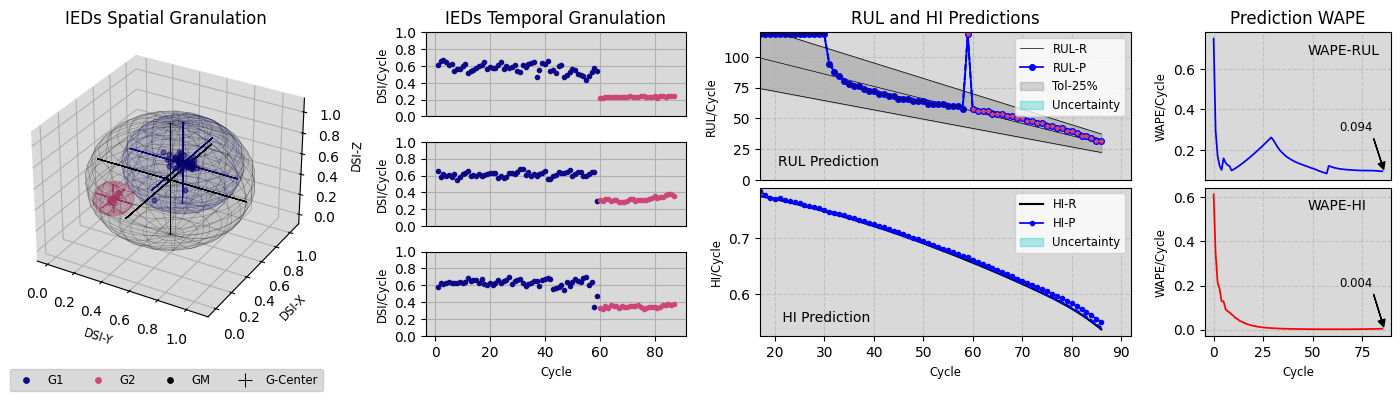

In [57]:
params_list = df_params.values[:,1:]

for i,params in enumerate(params_list):
    m,nI,nR,nO,mO,N1,N2,N3,τ,mode,act = params
    N1,N2,N3 = (1/(10**N1)),(1/(10**N2)),(1/(10**N3))
    X, Y, Z = PrepareData(RS, HI, nI, nO, mO, 1, mode)
    nI=len(Y[0])
    if isinstance(nR, str): nR = ast.literal_eval(nR)

    teda=AutoCloud(m=m,nI=nI,nR=nR,nO=nO+mO,ηS=[N1,N2,N3],mode=mode,act=act,
                tau=τ,rho=0.001,eol=0.3,ref=len(sig)-nI+1,wtaG=True,wtaP=True) 
    for j,_ in enumerate(X[:]):
        teda.run(X[j])
        teda.RUL_Prediction(Y[j],mode='interval',lim=len(sig)-nI+1,show=False)
        teda.Adapt(Y[j],Z[j])

    teda.c = np.append(teda.c,teda.gm)  
    #PlotSeriesPLY(ySeries=[teda.wape_HI_hist,teda.wape_RUL_hist])
    PlotDSI_3D_PLT(teda)

In [ ]:
m,nI,nR,nO,mO,N1,N2,N3,τ,mode,act = params_list[0]
X, Y, Z = PrepareData(RS, HI, nI, nO, mO, 1, mode)
nI = len(Y[0])
if isinstance(nR, str): nR = ast.literal_eval(nR)
n1,n2,n3 = (1/(10**N1)),(1/(10**N2)),(1/(10**N3))

teda=AutoCloud(m=m,nI=nI,nR=nR,nO=nO+mO,ηS=[n1,n2,n3],mode=mode,act=act,
               tau=τ,rho=0.001,eol=0.3,ref=len(sig)-nI+1,wtaG=True,wtaP=True) 
for j,_ in enumerate(X[:]):
    teda.run(X[j])
    teda.RUL_Prediction(Y[j],mode='interval',lim=len(sig)-nI+1,show=False)
    teda.Adapt(Y[j],Z[j])
teda.c = np.append(teda.c,teda.gm)  
PlotDSI_3D_PLT(teda)
